In [43]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import resin_spectral_analysis.data as data
from resin_spectral_analysis.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from resin_spectral_analysis.sourcespectrum import SourceSpectrum
from resin_spectral_analysis.utilities import ArrayParams
from resin_spectral_analysis.irradiance import Irradiance

In [1]:
import sys
!{sys.executable} --version

Python 3.7.6


# ArrayParams class

In [2]:
# class ArrayParams(typing.NamedTuple):
#     """Container with named attributes for making 1D arrays of values.
#     Intended for use with numpy.linspace.
#     """
#     min_value: float
#     max_value: float
#     num_pnts: int
        
temp = ArrayParams(300, 440, 11)
temp.min_value

300

In [3]:
print(*temp)

300 440 11


In [4]:
np.linspace(*temp)

array([300., 314., 328., 342., 356., 370., 384., 398., 412., 426., 440.])

# Irradiance class

In [5]:
# class Irradiance:
#     """Callable class that calculates the irradiance over an array of 
#     wavelengths for a given value of z in microns.
    
#     Parameters
#     ----------
#     source - SourceSpectrum
#         Spectrum of source
#     resin - Resin
#         Resin light propagates through
#     wavelength_array_params - ArrayParams
#         Minimum, maximum wavelength and number of points for array of wavelengths
        
        
#     Example
#     -------
#         # Create irradiance object for particular source, resin, and wavelength parameters
#         irradiance = Irradiance(
#             source=source,
#             resin=resin,
#             wavelength_array_params=wavelength_array_parameters
#         )
#         # Calculate the irradiance over wavelength array
#         irradiance_at_z_10_um = irradiance(10)
#         # Plot irradiance
#         fig, ax = plt.subplots()
#         ax.plot(irradiance.wavelengths, irradiance_at_z_10_um)
#     """
    
#     def __init__(self, source, resin, wavelength_array_params):
        
#         assert isinstance(source, SourceSpectrum)
#         assert isinstance(resin, Resin)
#         assert isinstance(wavelength_array_params, ArrayParams)
        
#         self.source = source
#         self.resin = resin
#         self.wavelength_array_params = wavelength_array_params
        
#         self.wavelengths = np.linspace(*self.wavelength_array_params)
        
#         self.source_spectrum = self.source.calc_power(self.wavelengths)
#         self.absorption_coeff_inv_um = self.resin.calc_absorption_coef_inv_um(self.wavelengths)
        
#     def __call__(self, z_um):
#         assert isinstance(z_um, (float, int))
#         temp = self.source_spectrum * np.exp(-self.absorption_coeff_inv_um * z_um)
#         return temp
        

## 365 nm LED with 370 nm short pass filter

In [6]:
plot_directory = Path('200328_plots')
plot_directory.resolve()

PosixPath('/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/notebooks/200328_plots')

In [7]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    0.38
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)
print(resin.name)

# Source
source = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Wavelength array parameters
wavelength_array_parameters = ArrayParams(300, 440, 401)

irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)

PEG-100__Avo-0.38__Irg-1


In [8]:
np.allclose(irradiance(0), source.calc_power(np.linspace(*wavelength_array_parameters)))

True

In [9]:
z_um_values = np.linspace(0, 60, 11)

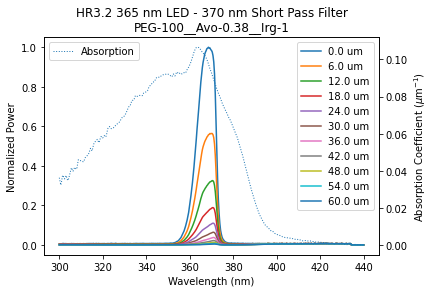

In [10]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance.wavelengths, irradiance(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance.wavelengths, resin.calc_absorption_coef_inv_um(irradiance.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR3.2 365 nm LED - 370 nm Short Pass Filter\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '365nm_short_pass_filter.png')

In [11]:
irradiance.wavelengths[1] - irradiance.wavelengths[0]

0.35000000000002274

## 365 nm LED - no filter

In [12]:
# Source
source2 = data.sources['HR3.2_365nm_no_filter-2019-12-31']

irradiance2 = Irradiance(source=source2, resin=resin, wavelength_array_params=wavelength_array_parameters)

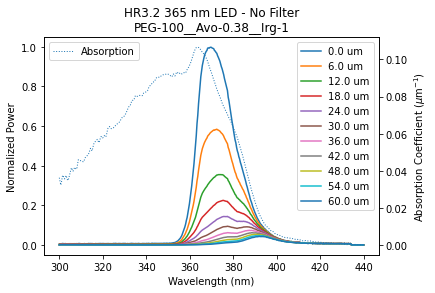

In [13]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance2.wavelengths, irradiance2(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance2.wavelengths, resin.calc_absorption_coef_inv_um(irradiance2.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR3.2 365 nm LED - No Filter\n" + resin.name)
ax.legend()
# plt.savefig(plot_directory.resolve() / '365nm_no_filter.png')

In [14]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f2ff90>,
 'Asiga_405nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f2fd90>,
 'HR1_385nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f13610>,
 'HR2_385nm_2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f13310>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f0cdd0>,
 'HR3.2_365nm_no_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f1c490>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f1f1d0>,
 'HR3.3_365nm_no_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f8e49f1a6d0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <resin

## 385 nm LED

In [15]:
# Source
source3 = data.sources['HR2_385nm_2020-03-23']

irradiance3 = Irradiance(source=source3, resin=resin, wavelength_array_params=wavelength_array_parameters)

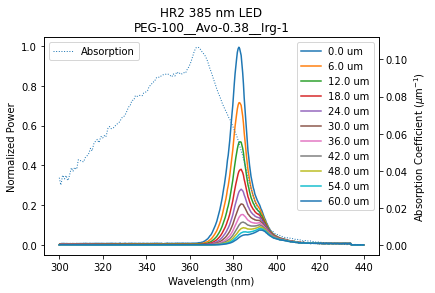

In [16]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance3.wavelengths, irradiance3(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance3.wavelengths, resin.calc_absorption_coef_inv_um(irradiance3.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR2 385 nm LED\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '385nm.png')

## 405 nm LED

In [17]:
# Source
source4 = data.sources['Asiga_405nm_100um_fiber-2016-12-14']

irradiance4 = Irradiance(source=source4, resin=resin, wavelength_array_params=wavelength_array_parameters)

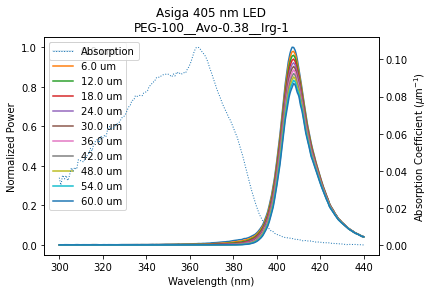

In [18]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance4.wavelengths, irradiance4(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance4.wavelengths, resin.calc_absorption_coef_inv_um(irradiance4.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("Asiga 405 nm LED\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '405nm.png')

In [19]:
test_irradiance = irradiance(10)
test_irradiance

array([0.00332582, 0.0032464 , 0.00393413, 0.00413325, 0.00448637,
       0.00505762, 0.0047063 , 0.00431655, 0.0045632 , 0.00432861,
       0.00408764, 0.00415234, 0.00422854, 0.00359228, 0.0045277 ,
       0.00365733, 0.00457454, 0.00410781, 0.00396655, 0.00442195,
       0.00379248, 0.00351975, 0.00406563, 0.00374028, 0.00418649,
       0.0033879 , 0.00345082, 0.0040607 , 0.0040394 , 0.00379553,
       0.00363247, 0.00391328, 0.00415637, 0.00386412, 0.00344776,
       0.00399324, 0.004092  , 0.00404077, 0.00407606, 0.00440475,
       0.00416372, 0.00406622, 0.00405867, 0.00421772, 0.00398996,
       0.00452115, 0.00329778, 0.00375411, 0.00383309, 0.0041933 ,
       0.00356805, 0.00392237, 0.00421141, 0.003607  , 0.00362303,
       0.00344974, 0.00347303, 0.00375536, 0.00364259, 0.00415409,
       0.00382525, 0.00309562, 0.00358905, 0.00346407, 0.00400801,
       0.0033227 , 0.0034512 , 0.00395645, 0.00425953, 0.00423648,
       0.00358172, 0.0036921 , 0.00326663, 0.0038494 , 0.00430

# 3D plots

See 

- [An easy introduction to 3D plotting with Matplotlib](https://towardsdatascience.com/an-easy-introduction-to-3d-plotting-with-matplotlib-801561999725)
- [Beyond data scientist: 3d plots in Python with examples](https://medium.com/@yzhong.cs/beyond-data-scientist-3d-plots-in-python-with-examples-2a8bd7aa654b)
- [Maximum intensity projection](https://en.wikipedia.org/wiki/Maximum_intensity_projection)

In [21]:
temp = ArrayParams(0, 60, 11)
z_um_values = np.linspace(*temp)
z_um_values

array([ 0.,  6., 12., 18., 24., 30., 36., 42., 48., 54., 60.])

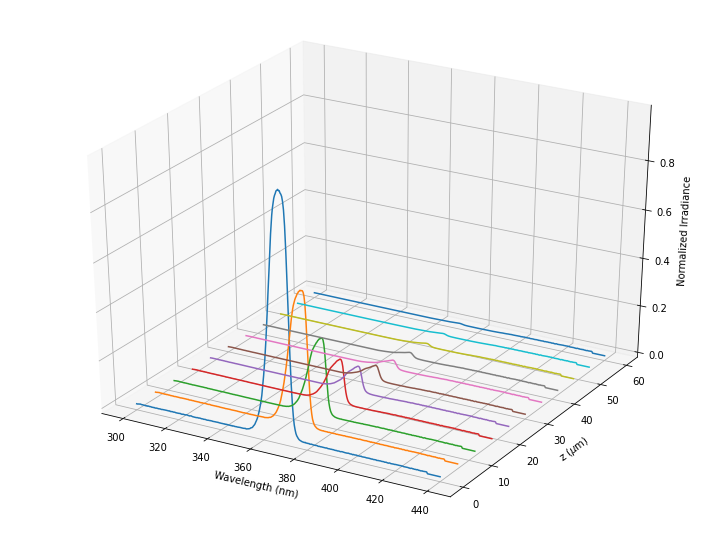

In [27]:
plt.rcParams["figure.figsize"] = 12.8, 9.6

yline = np.ones(len(irradiance.wavelengths))

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("z ($\mu$m)")
ax.set_zlabel("Normalized Irradiance")

for z_um in z_um_values:
    ax.plot3D(irradiance.wavelengths, yline * z_um, irradiance(z_um)) #, label=f"{z_um} um")


In [56]:
def plot3D(irradiance, z_um_values, figsize=(12.8, 9.6), **kwargs):
    yline = np.ones(len(irradiance.wavelengths))

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection="3d")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("z ($\mu$m)")
    ax.set_zlabel("Normalized Irradiance")

    for z_um in z_um_values:
        ax.plot(irradiance.wavelengths, yline * z_um, irradiance(z_um), **kwargs)

    return fig, ax

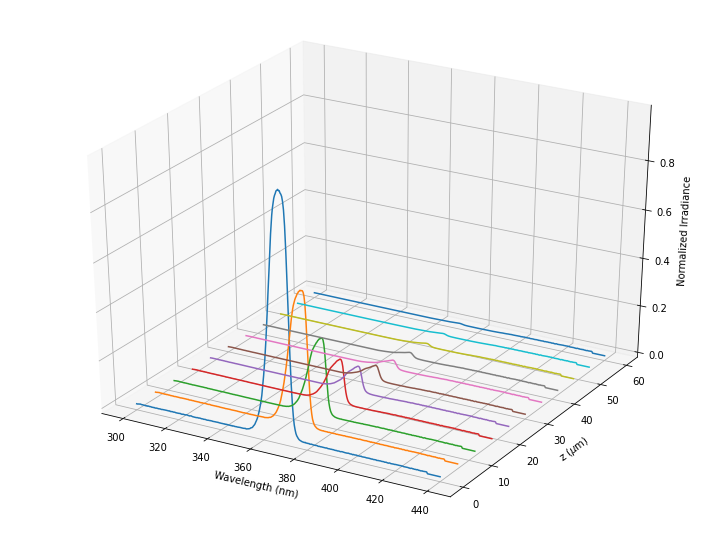

In [57]:
plot3D(irradiance, z_um_values);

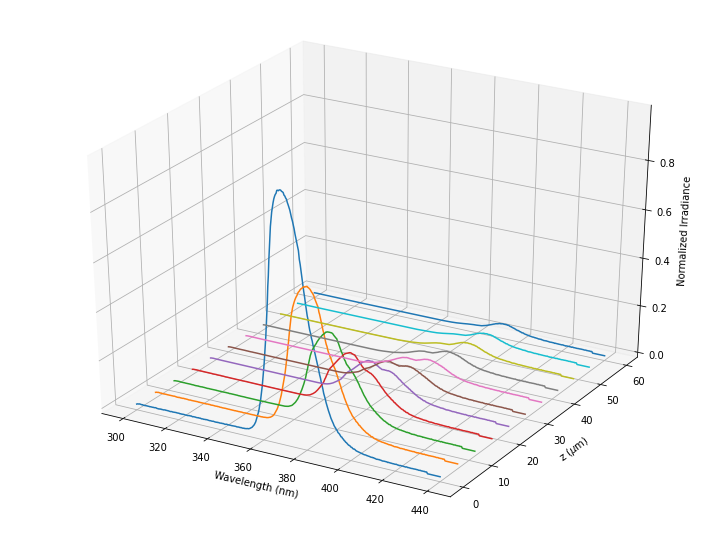

In [58]:
plot3D(irradiance2, z_um_values);

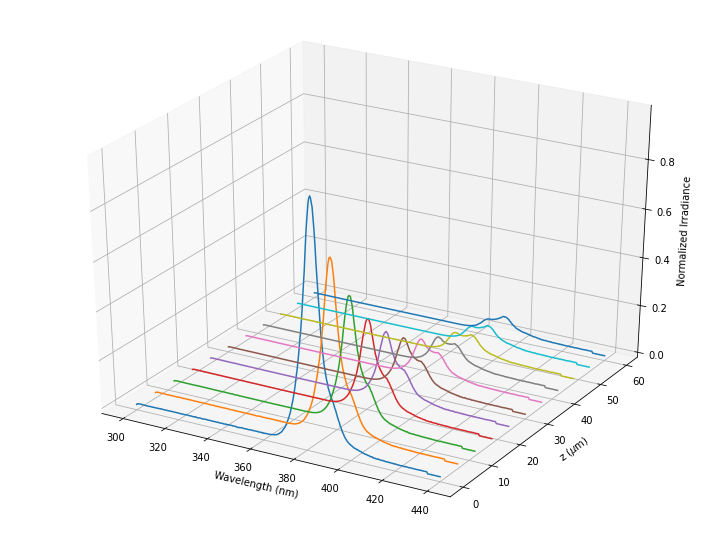

In [59]:
plot3D(irradiance3, z_um_values);

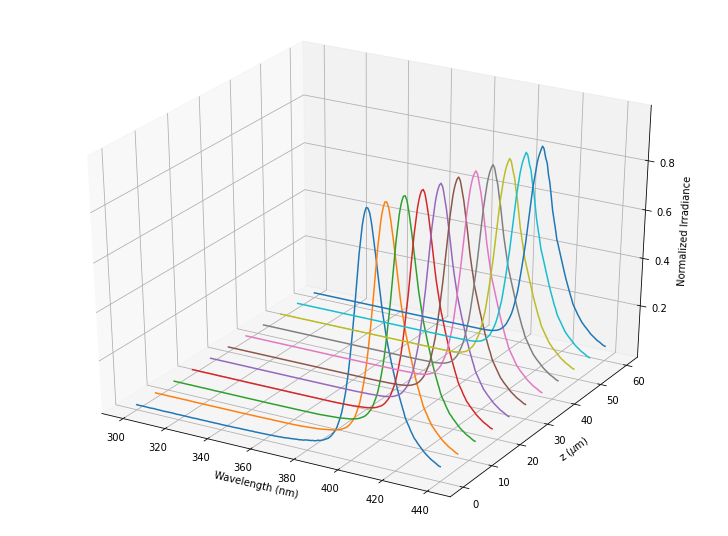

In [60]:
plot3D(irradiance4, z_um_values);

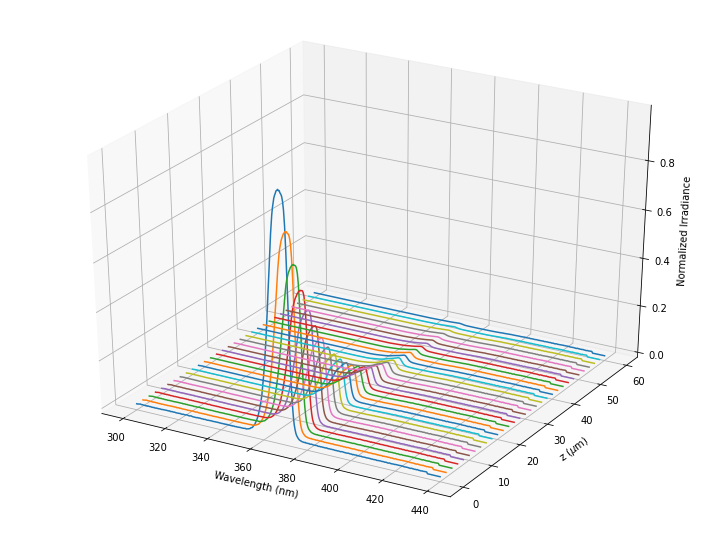

In [61]:
z_um_values2 = np.linspace(0, 60, 31)
plot3D(irradiance, z_um_values2);

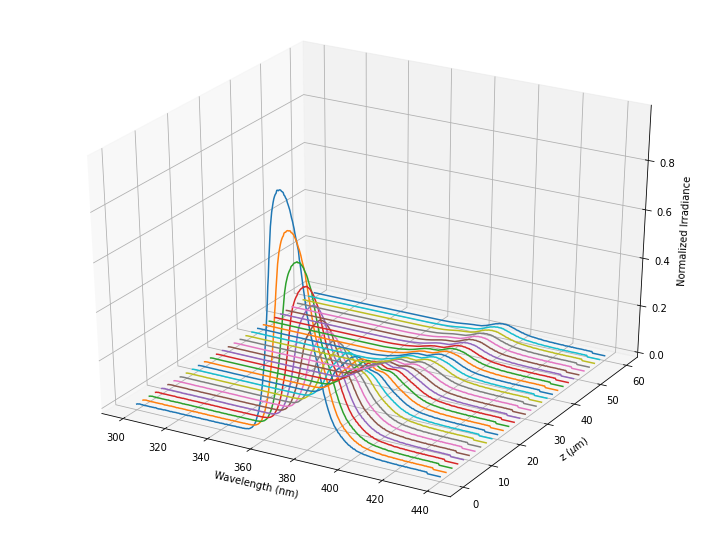

In [62]:
plot3D(irradiance2, z_um_values2);

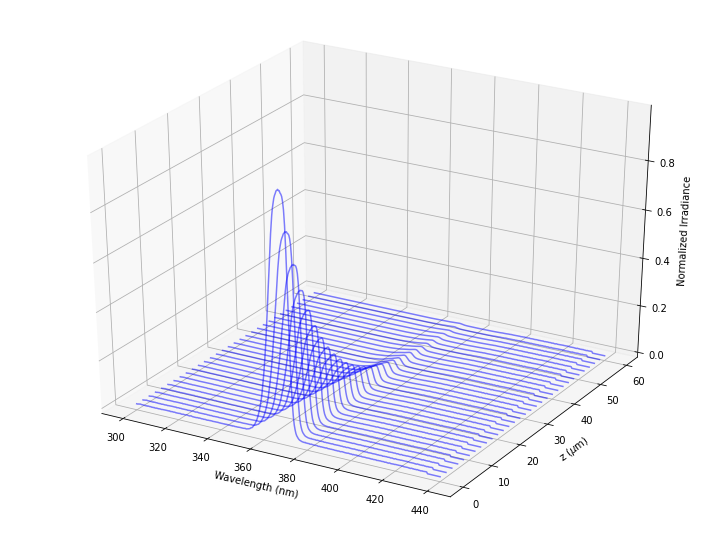

In [68]:
plot3D(irradiance, z_um_values2, color='blue', alpha=0.5);

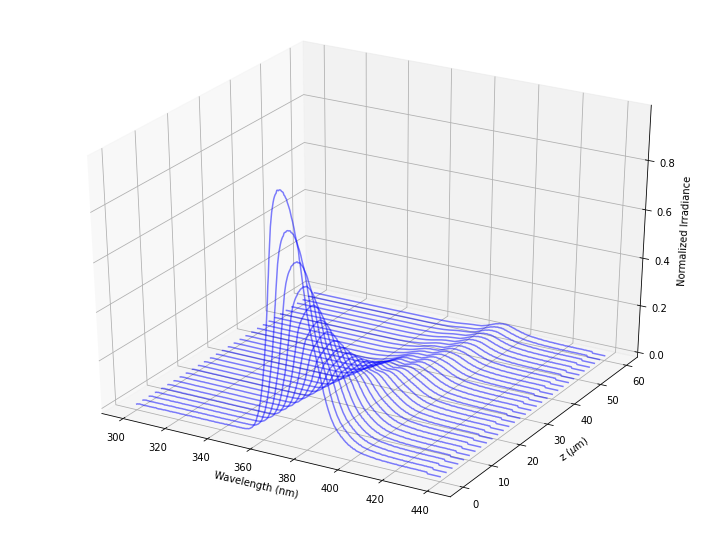

In [69]:
plot3D(irradiance2, z_um_values2, color='blue', alpha=0.5);